# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, *_ = rat_lists
root = r"d:\Thesis\ALLDATA"
sequence = {}
for index, animal in enumerate(intact_rats):
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal, session, name="sequence.p")


Found 0 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

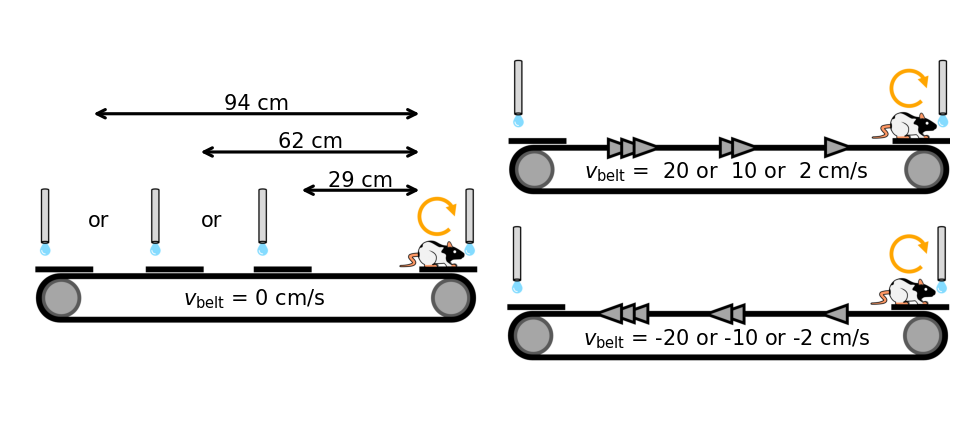

In [4]:
def Figure3A(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Aidle.png"

    img = plt.imread(path)
    img = img[300:2600, 150:3075]
    img = np.concatenate((np.ones((300, img.shape[1], 3), dtype=np.uint8), img), axis=0)
    
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ = 0 cm/s', x=img.shape[1]/2, y=1760, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=450, y=1250, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=1185, y=1250, ha="center", va="center", fontsize=5)

    ax.annotate(text='', xy=(1720, 1050), xytext=(2600, 1050), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(1060, 800), xytext=(2600, 800), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(360, 550), xytext=(2600, 550), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    
    ax.annotate(text='29 cm', xy=(0, 0), xytext=((1720+2600)/2, 1050), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='62 cm', xy=(0, 0), xytext=((1060+2600)/2, 800), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='94 cm', xy=(0, 0), xytext=((360+2600)/2, 550), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)

def Figure3D(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Didle.png"

    img = plt.imread(path)
    img = img[:, 150:3075]
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ =  20 or  10 or  2 cm/s', x=img.shape[1]/2, y=930, ha="center", va="center", fontsize=5)
    ax.text(s=r'$v_{\mathrm{belt}}$ = -20 or -10 or -2 cm/s', x=img.shape[1]/2, y=2020, ha="center", va="center", fontsize=5)

fig, axs = plt.subplots(1, 2, figsize=(cm2inch(8), cm2inch(4)))
Figure3A(ax=axs[0])
Figure3D(ax=axs[1])

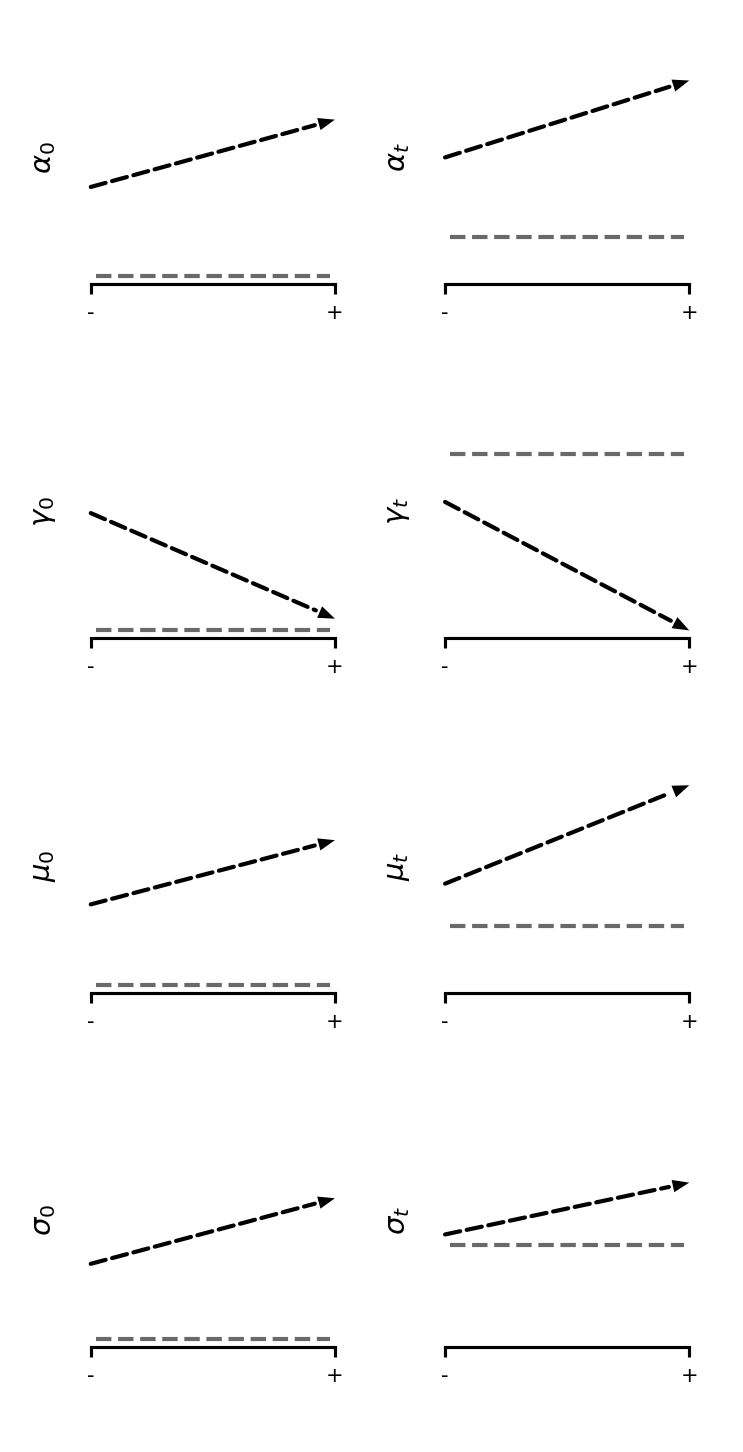

In [8]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, ex_fit=ex_alpha_0, yticks=GENERAL_PLOT_PARAMS['alpha_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['alpha_0']['ylabel'], start='med', end=2),
    'alpha_t':  dict(fit=alpha_t, ex_fit=ex_alpha_t, yticks=GENERAL_PLOT_PARAMS['alpha_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['alpha_t']['ylabel'], start='med', end=0.4),
    'gamma_0':  dict(fit=gamma_0, ex_fit=ex_gamma_0, yticks=GENERAL_PLOT_PARAMS['gamma_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['gamma_0']['ylabel'], start=1, end=.1),
    'gamma_t':  dict(fit=gamma_t, ex_fit=ex_gamma_t, yticks=GENERAL_PLOT_PARAMS['gamma_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['gamma_t']['ylabel'], start='med', end=-.15),
    'mu_0':     dict(fit=mu_0, ex_fit=ex_mu_0, yticks=GENERAL_PLOT_PARAMS['mu_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['mu_0']['ylabel'], start='med', end='med'),
    'mu_t':     dict(fit=mu_t, ex_fit=ex_mu_t, yticks=GENERAL_PLOT_PARAMS['mu_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['mu_t']['ylabel'], start='med', end=.12),
    'sigma_0':  dict(fit=sigma_0, ex_fit=ex_sigma_0, yticks=GENERAL_PLOT_PARAMS['sigma_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['sigma_0']['ylabel'], start='med', end=.15),
    'sigma_t':  dict(fit=sigma_t, ex_fit=ex_sigma_t, yticks=GENERAL_PLOT_PARAMS['sigma_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['sigma_t']['ylabel'], start='med', end=0.04),
}

def plot_prediction(param_name, ax=None, show_xlabel=False, show_ylabel=True, intact_rats=intact_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]

    if isinstance(params['start'], str):
        if params['start'] == 'med':
            start = np.median([params['fit'][animal]["60"] for animal in intact_rats])
    elif isinstance(params['start'], (float, int)):
        start = params['start']
    else:
        raise ValueError("Start value must be a string ('med') or a float/int.")

    if isinstance(params['end'], str):
        if params['end'] == 'med':
            end = np.median([params['fit'][animal]["rev20"] for animal in intact_rats])
        if params['end'] == 'start':
            end = start
    elif isinstance(params['end'], (float, int)):
        end = params['end']
    else:
        raise ValueError("End value must be a string ('med', 'start') or a float/int.")

    mock_data = [start, start + (end - start) / 2, end]
    # ax.plot([0, 1, 2], mock_data, color='k', lw=.75, markersize=2, linestyle='-')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)


    arrowStart = (0, mock_data[0])
    arrowStop = (2, mock_data[2])
    arrowColor = 'k'
    ax.annotate("", arrowStop, xytext=arrowStart, arrowprops=dict(arrowstyle="-", shrinkA=0, shrinkB=5, edgecolor=arrowColor, facecolor="none", linestyle="dashed"))
    ax.annotate("", arrowStop, xytext=arrowStart, arrowprops=dict(linewidth=0, arrowstyle="-|>,head_width=0.15,head_length=0.4", shrinkA=0, shrinkB=0, edgecolor="none", facecolor=arrowColor, linestyle="solid"))


    ax.set_xlim(0, 2)
    ax.set_xticks([0, 2])
    ax.set_xticklabels(["-", "+"])
    if show_xlabel:
        ax.set_xlabel("Cost")
    else:
        ax.set_xlabel(" ")


    ax.set_ylim(params['yticks'][0], params['yticks'][-1])
    ax.set_yticks(params['yticks'])
    ax.yaxis.set_major_formatter('{x:<5.2f}')
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, labelleft=False)

    if show_ylabel:
        ax.set_ylabel(params['ylabel'])

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1, top_y=0.05)


fig, axs = plt.subplots(4, 2, figsize=(cm2inch(6), cm2inch(12)))

param_names = ['alpha_0', 'alpha_t', 'gamma_0', 'gamma_t',
                'mu_0', 'mu_t', 'sigma_0', 'sigma_t']

for ax, param_name in zip(axs.ravel(), param_names):
    plot_prediction(param_name, ax=ax)


# 3B Effect of distance on α0, αt and αu
# 3C Effect of distance on γ0, γt and γu

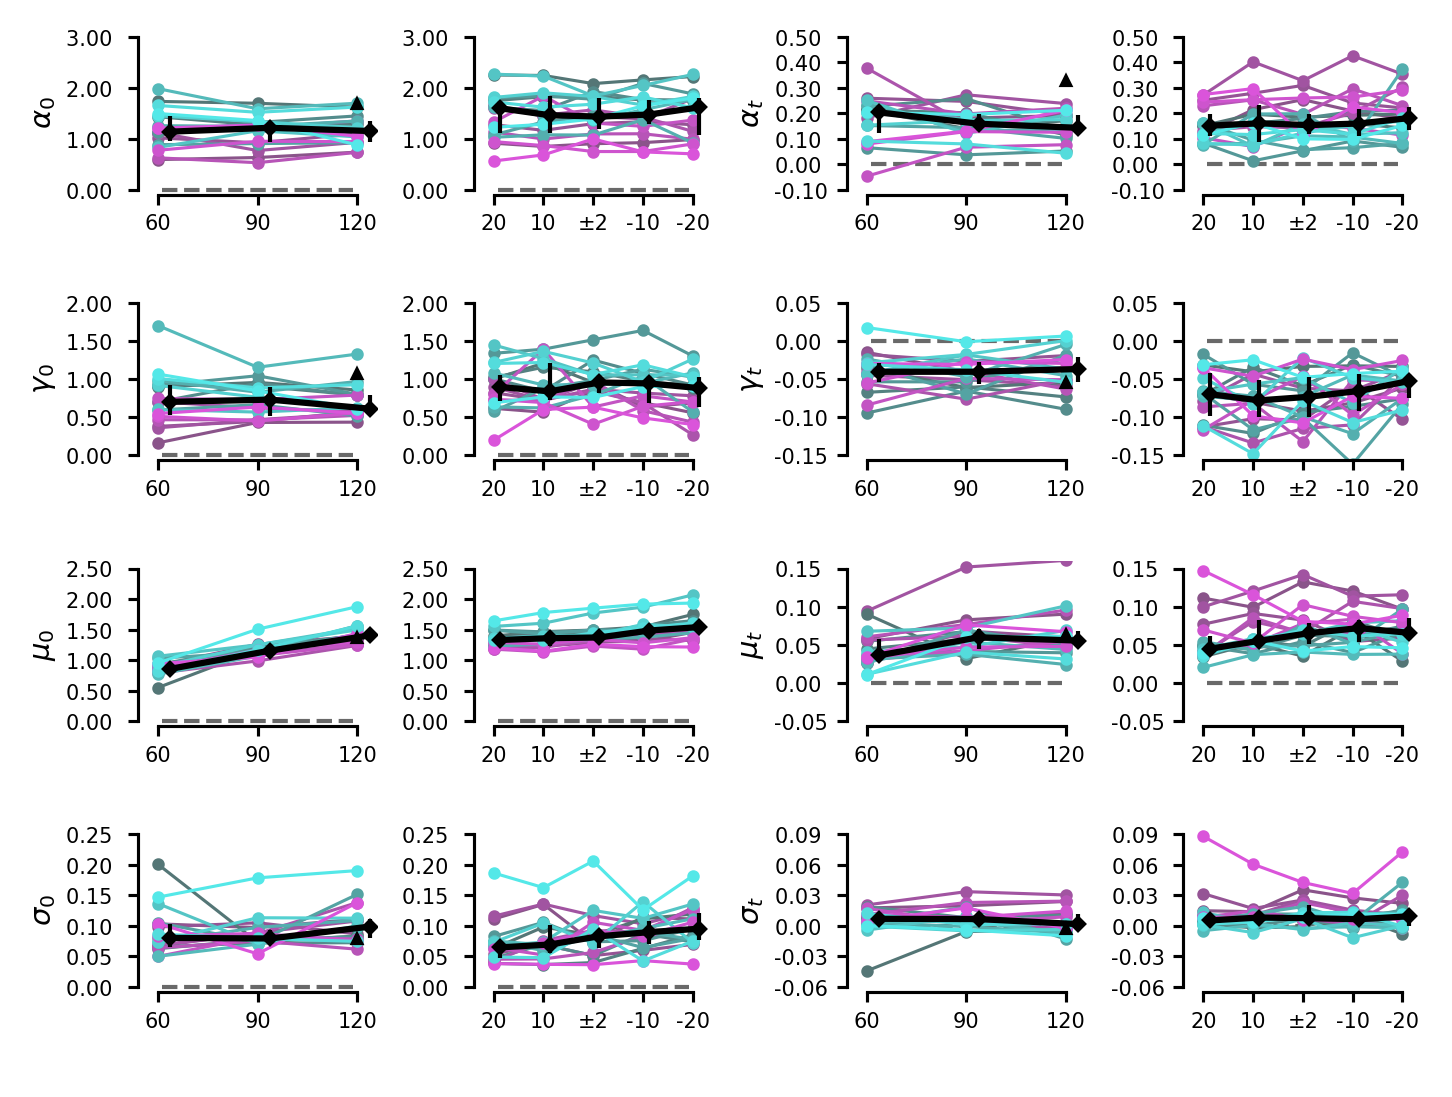

In [9]:


fig, axs = plt.subplots(4, 4, figsize=(cm2inch(12), cm2inch(9)))
param_names = [name for name in list(PLOT_PARAMS.keys()) for _ in (0, 1)]

for i, ax in enumerate(axs.ravel()):
    if i % 2 == 0:
        dist_or_tm = 'dist'
    else:
        dist_or_tm = 'tm'

    show_xlabel = True if i >= 18 else False
    show_ylabel = True if i % 2 == 0 else False
    show_ex = True if i % 2 == 0 else False
    plot_model_parameter(PLOT_PARAMS[param_names[i]], rat_markers, dist_or_tm=dist_or_tm, show_ex=show_ex, ax=ax, 
                         animal_list=intact_rats, show_xlabel=show_xlabel, show_ylabel=show_ylabel)


# 3E Effect of treadmill on α0, αt and αu
# 3F Effect of treadmill on γ0, γt and γu

# Figure 3: Dynamics of decision parameters across action costs.

C:\Users\Timmel\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
C:\Users\Timmel\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


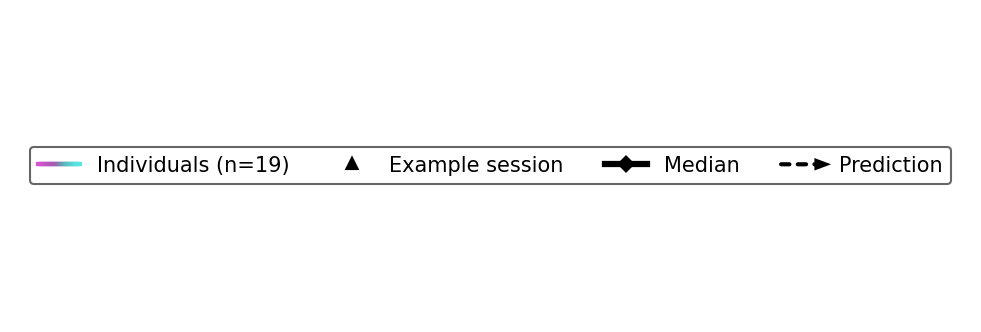

In [10]:

def dummy_legend(ax=None, animal_list=intact_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ex_session = ax.plot(2, 0, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    median = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median', zorder=5)

    class DashedArrowHandler(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent,
                        width, height, fontsize, trans):
            scale = 1.4
            extra = (scale - 1) * width / 2
            start_x = -extra
            end_x = width + extra

            y = 0.5 * height

            # Dashed shaft
            shaft = mpatches.FancyArrowPatch((start_x, y), (end_x, y),
                                            arrowstyle='-',
                                            linestyle=(0, (2, 2)),
                                            lw=1,
                                            color='k',
                                            mutation_scale=fontsize)
            # Solid head
            head = mpatches.FancyArrowPatch((start_x + 0.8*(end_x-start_x), y), (end_x, y),
                                            arrowstyle='-|>,head_width=.3,head_length=.8',
                                            lw=0,
                                            facecolor='k',
                                            edgecolor='k',
                                            mutation_scale=fontsize)

            shaft.set_transform(trans)
            head.set_transform(trans)
            return [shaft, head]


    arrow = mpatches.FancyArrowPatch((0, 0), (1, 0),
                                     arrowstyle='-|>', 
                                     lw=1, 
                                     color='k',
                                     linestyle='--')
    

    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

    add_colored_intact(ax, handles=[ex_session, median, arrow], ncol=4,
                    labels=['Example session', 'Median', 'Prediction'], text=f'Individuals (n={len(animal_list)})', 
                    loc='center', bbox=(.5, .5), handler_map={mpatches.FancyArrowPatch: DashedArrowHandler()})


fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

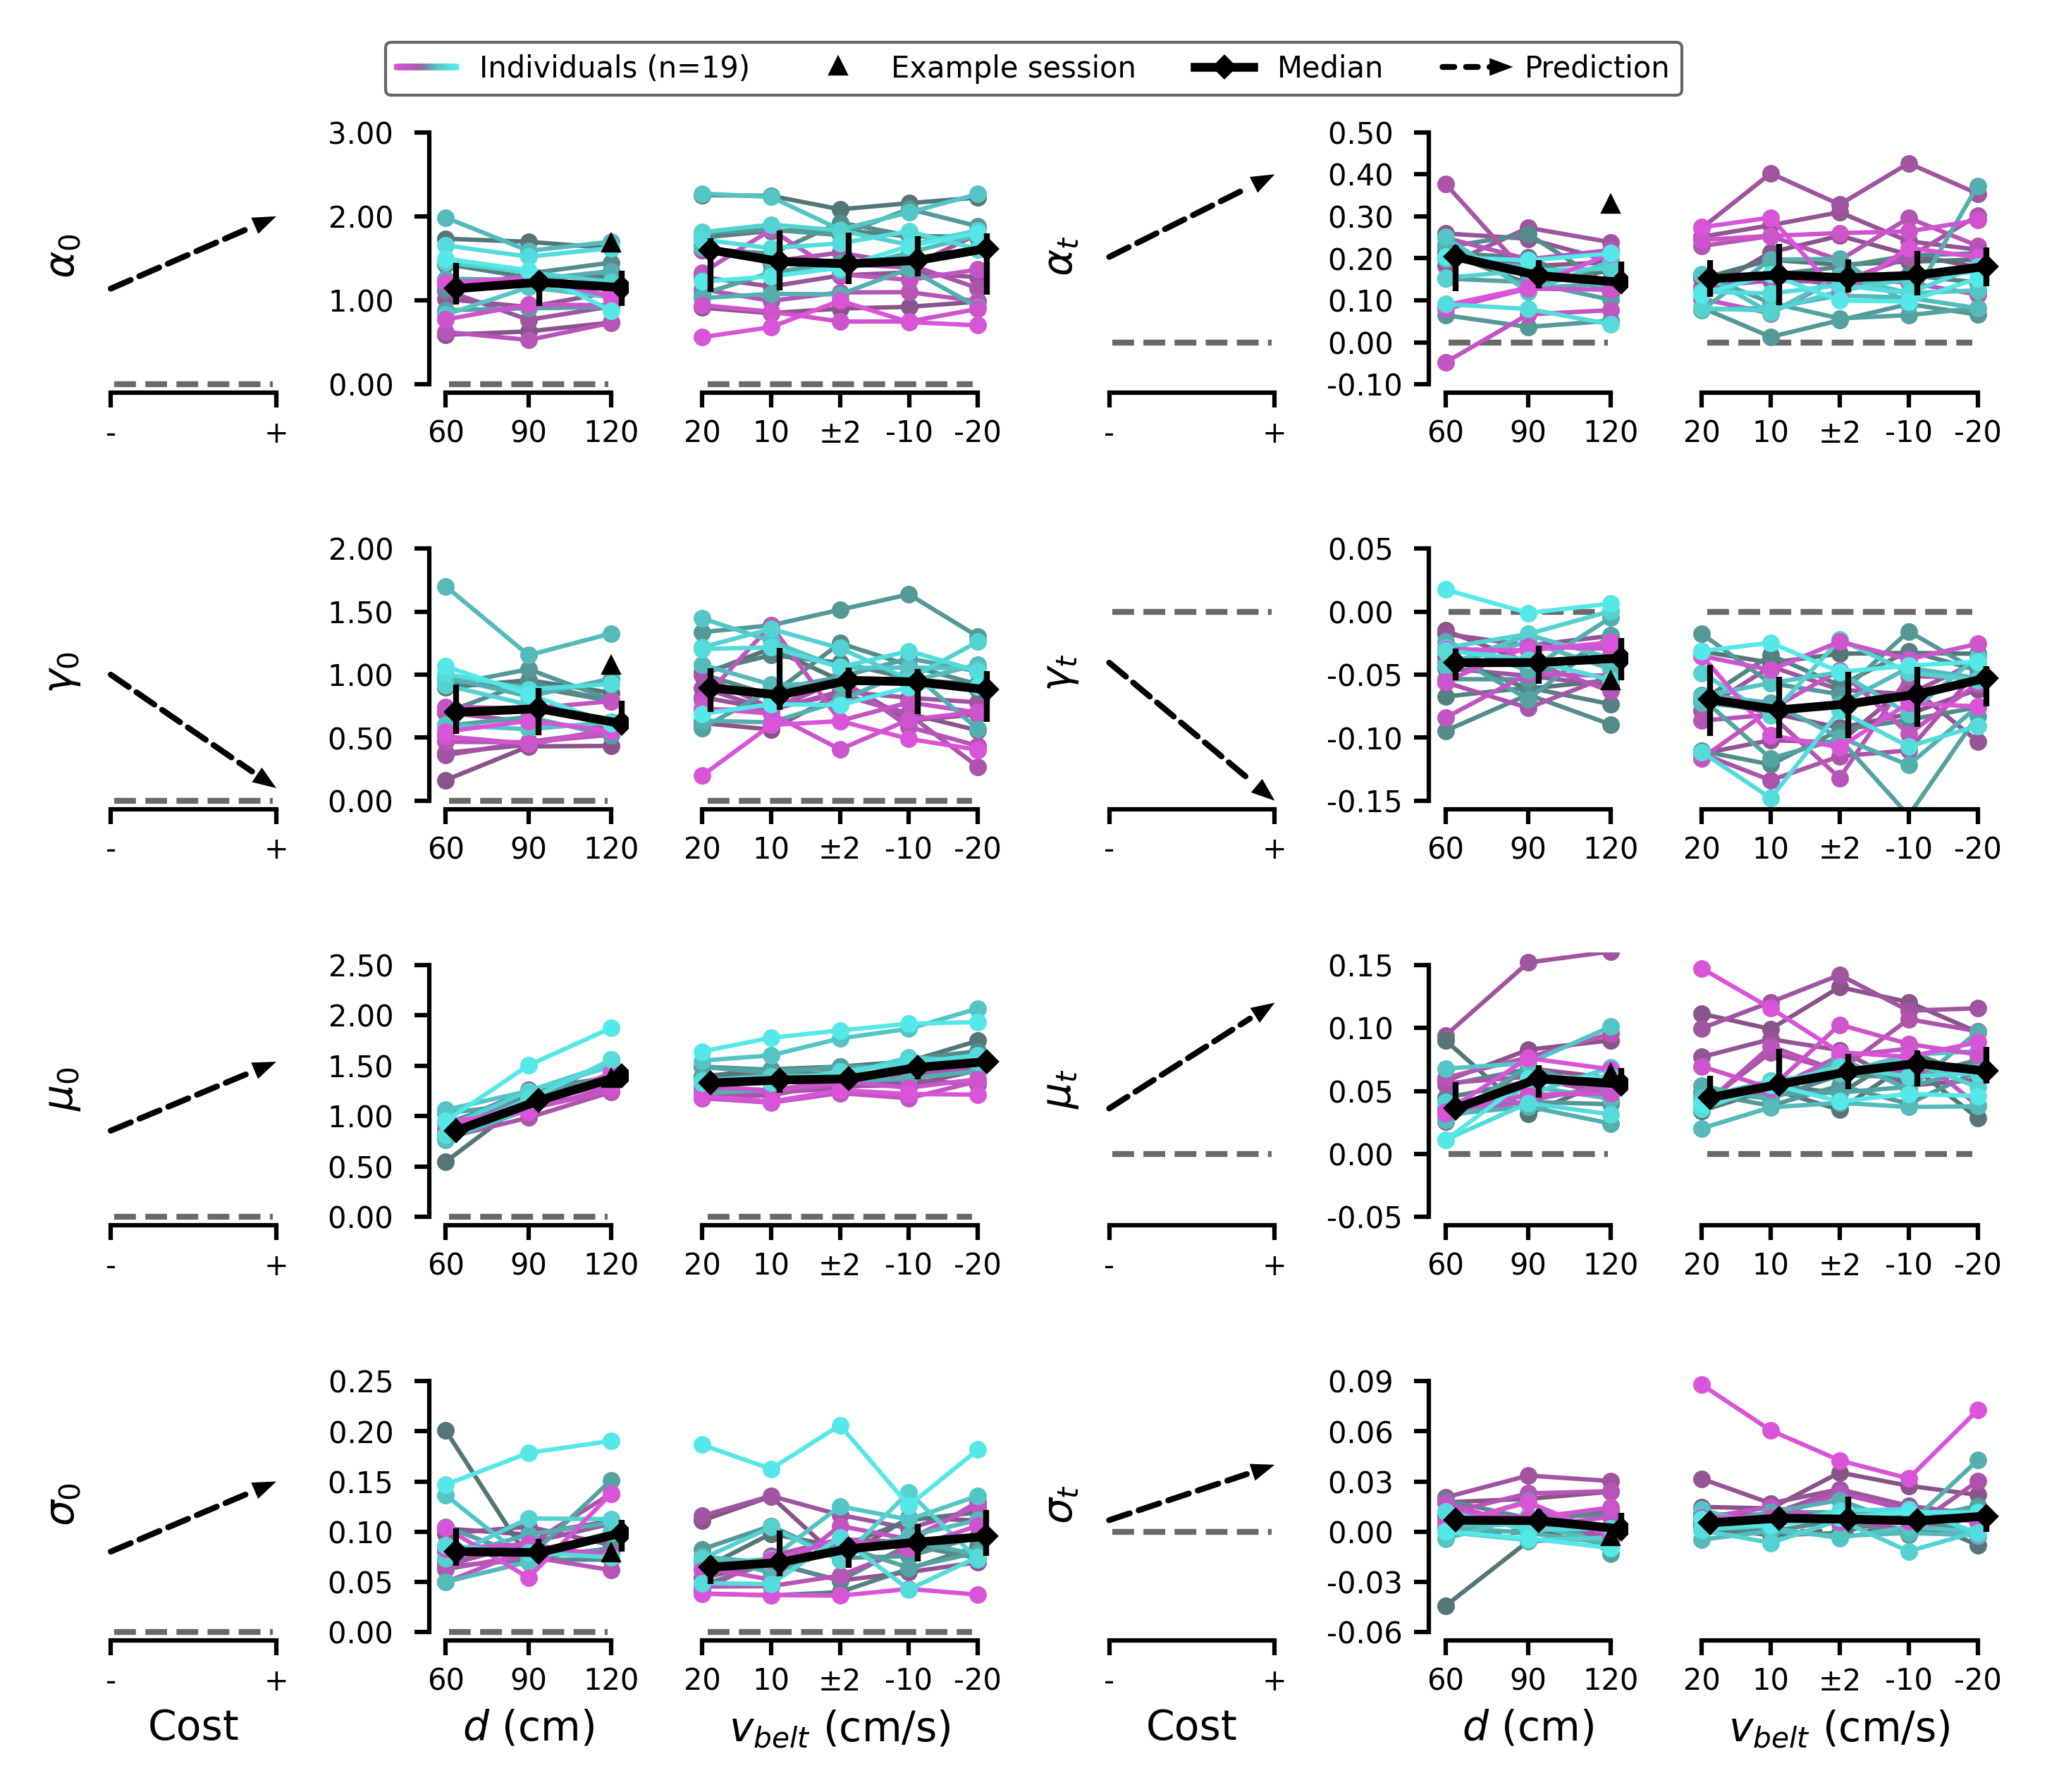

In [12]:

fig = plt.figure(figsize=(cm2inch(12), cm2inch(10)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.0001
width_ratios = [3, 3, 5, pad, 3, 3, 5]
gs0 = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1])

row1 = gs0[0].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_alpha_0 = plt.subplot(row1[0])
fit_alpha_0_distance = plt.subplot(row1[1])
fit_alpha_0_vbelt = plt.subplot(row1[2])

ax_prediction_alpha_t = plt.subplot(row1[4])
fit_alpha_t_distance = plt.subplot(row1[5])
fit_alpha_t_vbelt = plt.subplot(row1[6])

row2 = gs0[1].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_gamma_0 = plt.subplot(row2[0])
fit_gamma_0_distance = plt.subplot(row2[1])
fit_gamma_0_vbelt = plt.subplot(row2[2])

ax_prediction_gamma_t = plt.subplot(row2[4])
fit_gamma_t_distance = plt.subplot(row2[5])
fit_gamma_t_vbelt = plt.subplot(row2[6])


row3 = gs0[2].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_mu_0 = plt.subplot(row3[0])
fit_mu_0_distance = plt.subplot(row3[1])
fit_mu_0_vbelt = plt.subplot(row3[2])

ax_prediction_mu_t = plt.subplot(row3[4])
fit_mu_t_distance = plt.subplot(row3[5])
fit_mu_t_vbelt = plt.subplot(row3[6])

row4 = gs0[3].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_sigma_0 = plt.subplot(row4[0])
fit_sigma_0_distance = plt.subplot(row4[1])
fit_sigma_0_vbelt = plt.subplot(row4[2])

ax_prediction_sigma_t = plt.subplot(row4[4])
fit_sigma_t_distance = plt.subplot(row4[5])
fit_sigma_t_vbelt = plt.subplot(row4[6])



plot_prediction('alpha_0', ax=ax_prediction_alpha_0, show_ylabel=True)
plot_prediction('alpha_t', ax=ax_prediction_alpha_t)
plot_prediction('gamma_0', ax=ax_prediction_gamma_0)
plot_prediction('gamma_t', ax=ax_prediction_gamma_t)
plot_prediction('mu_0', ax=ax_prediction_mu_0)
plot_prediction('mu_t', ax=ax_prediction_mu_t)
plot_prediction('sigma_0', ax=ax_prediction_sigma_0, show_xlabel=True)
plot_prediction('sigma_t', ax=ax_prediction_sigma_t, show_xlabel=True)


plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_0_distance, animal_list=intact_rats, show_ylabel=False)
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_t_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_0_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_t_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_0_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_t_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_0_distance, animal_list=intact_rats, show_xlabel=True)
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_t_distance, animal_list=intact_rats, show_xlabel=True)


plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_0_vbelt, animal_list=intact_rats, hide_y=True)
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_t_vbelt, animal_list=intact_rats, hide_y=True)
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_0_vbelt, animal_list=intact_rats, hide_y=True)
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_t_vbelt, animal_list=intact_rats, hide_y=True)
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_0_vbelt, animal_list=intact_rats, hide_y=True)
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_t_vbelt, animal_list=intact_rats, hide_y=True)
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_0_vbelt, animal_list=intact_rats, show_xlabel=True, hide_y=True)
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_t_vbelt, animal_list=intact_rats, show_xlabel=True, hide_y=True)

legend = fig.add_axes([.5, 1.015, .01, .01])
dummy_legend(ax=legend)

plt.savefig("./Figures_paper/Figure_3.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_3.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)